# NOTEBOOK: Decision Tree Classifier

 Goal: Implement and evaluate Decision Tree Classifier

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import data_loader
from src.eda import (
    analyze_data,
    plot_feature_distributions_by_class
)
from src.preprocessing import DataPreprocessor
from src.data_utils import split_train_test
from src.models.supervised import SKLearnDecisionTreeClassifier, SKLearnLDA

from src.models.supervised.model_selection import (
    k_fold_cross_validation, 
    plot_cross_validation_results,
    grid_search_cv,
    plot_grid_search_results
)

2025-12-29 23:37:19.251674: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Data Loading & Exploration

DATA ANALYSIS

Dataset shape: 891 rows × 7 columns

Data types:
Pclass        int64
Sex          object
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked     object
dtype: object

Missing values:
          Missing_Count  Missing_Percent
Age                 177            19.87
Embarked              2             0.22

Numerical columns (5):
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

Categorical columns (2):
['Sex', 'Embarked']

Numerical features statistics:
           Pclass         Age       SibSp       Parch        Fare
count  891.000000  714.000000  891.000000  891.000000  891.000000
mean     2.308642   29.699118    0.523008    0.381594   32.204208
std      0.836071   14.526497    1.102743    0.806057   49.693429
min      1.000000    0.420000    0.000000    0.000000    0.000000
25%      2.000000   20.125000    0.000000    0.000000    7.910400
50%      3.000000   28.000000    0.000000    0.000000   14.454200
75%      3.000000   38.000000    1

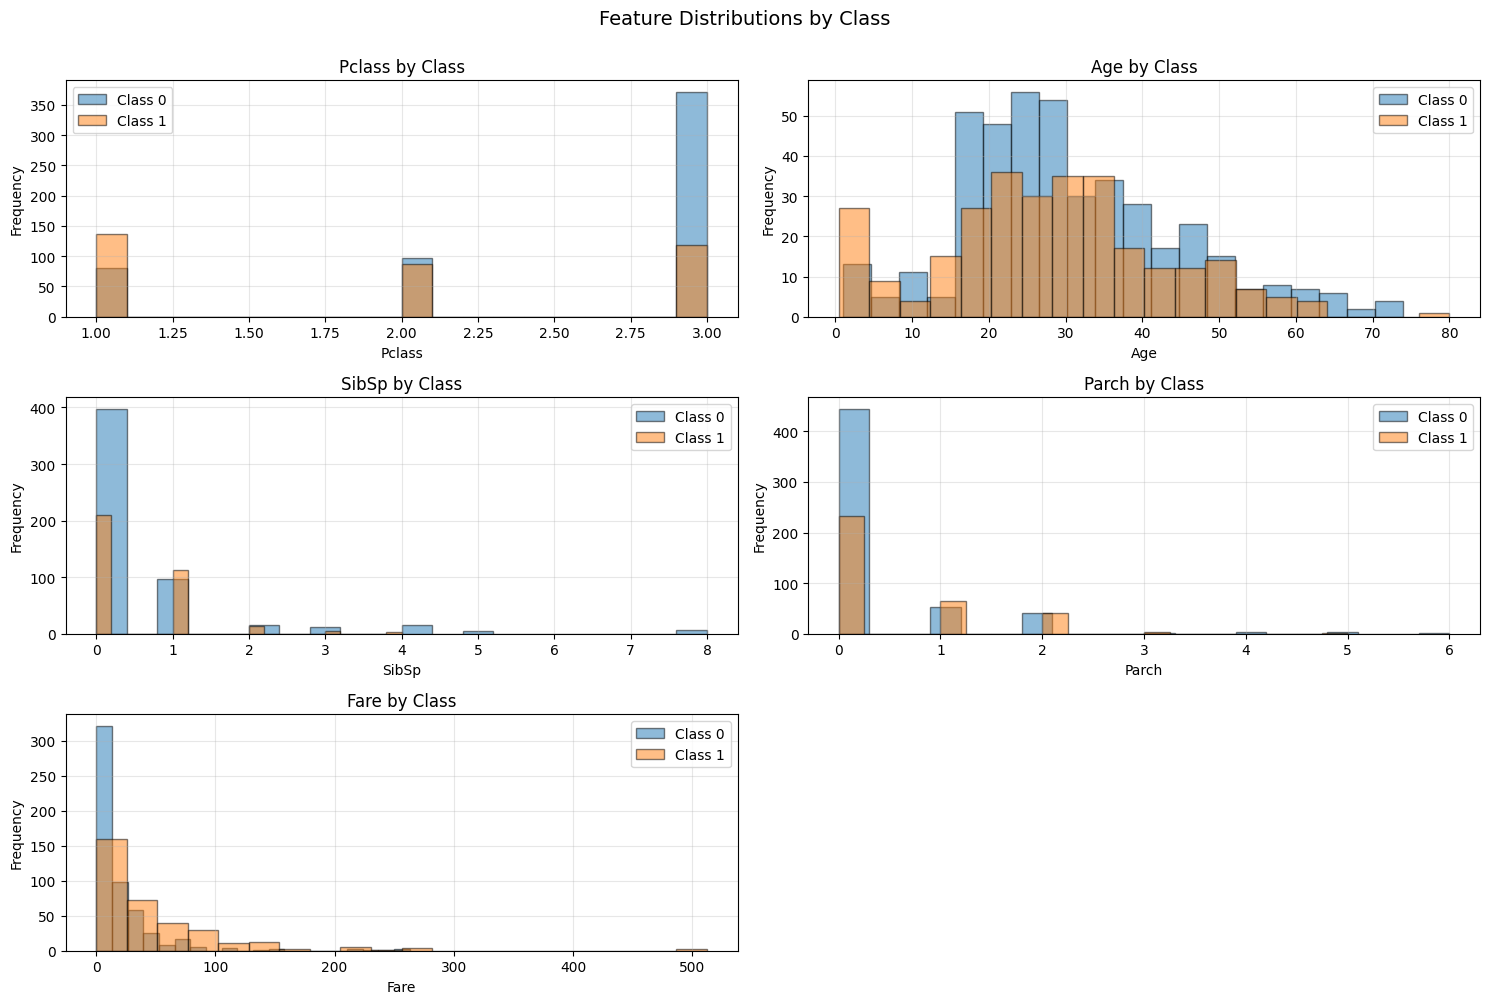

In [2]:
# Load data
# Quick EDA: shape, dtypes, missing values, class distribution
# Feature/target split

X, y = data_loader.load_titanic()

analyze_data(X, show_stats=True)
plot_feature_distributions_by_class(X, y)

## Preprocess Data

In [3]:
# Split
X_train, X_test, y_train, y_test = split_train_test(X, y, test_size=0.2, random_state=42)

# Preprocess
preprocessor = DataPreprocessor(scale=False, encode_categorical=True) # No scaling for tree-based models
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print(f"Training set: {X_train_proc.shape}")
print(f"Test set: {X_test_proc.shape}")
print(f"\nFeature names after preprocessing:")
print(preprocessor.get_feature_names())


DataPreprocessor: fit_transform

1. Column types:
   Numerical: 5 columns
   Nominal categorical: 2 columns
   Ordinal categorical: 0 columns

2. Processing numerical columns...
   ✓ Applied median imputation

3. Processing nominal categorical columns...
   ✓ Applied most_frequent imputation
   ✓ One-hot encoding 2 nominal columns...
   → Created 5 one-hot features

4. Processing ordinal categorical columns...

Final shape: 712 rows × 10 features

Training set: (712, 10)
Test set: (179, 10)

Feature names after preprocessing:
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S']


## Baseline Model

In [4]:
model = SKLearnDecisionTreeClassifier()
model.fit(X_train_proc, y_train)

baseline_score = model.score(X_test_proc, y_test)
print(f"Baseline accuracy: {baseline_score:.4f}")

Baseline accuracy: 0.7765


## Baseline Evaluation & Diagnostics


BASELINE MODEL EVALUATION
Test Accuracy: 0.7765

Confusion Matrix:


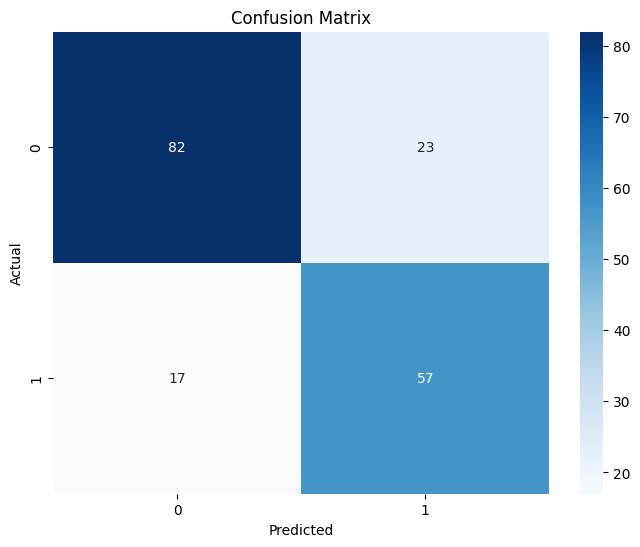

In [5]:
print("\n" + "="*70)
print("BASELINE MODEL EVALUATION")
print("="*70)
print(f"Test Accuracy: {baseline_score:.4f}")

# Confusion matrix (brief)
print("\nConfusion Matrix:")
cm = model.confusion_matrix(X_test_proc, y_test)
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

## K-Fold Cross-Validation for Robust Evaluation


K-FOLD CROSS-VALIDATION
K-FOLD CROSS-VALIDATION (k=5)
Task: Classification
Scoring: accuracy
Total samples: 712

Fold 1/5: accuracy=0.7902 (train: 569, test: 143)
Fold 2/5: accuracy=0.8182 (train: 569, test: 143)
Fold 3/5: accuracy=0.7535 (train: 570, test: 142)
Fold 4/5: accuracy=0.7676 (train: 570, test: 142)
Fold 5/5: accuracy=0.7394 (train: 570, test: 142)

CROSS-VALIDATION RESULTS
Mean accuracy: 0.7738 ± 0.0278
Min accuracy:  0.7394
Max accuracy:  0.8182


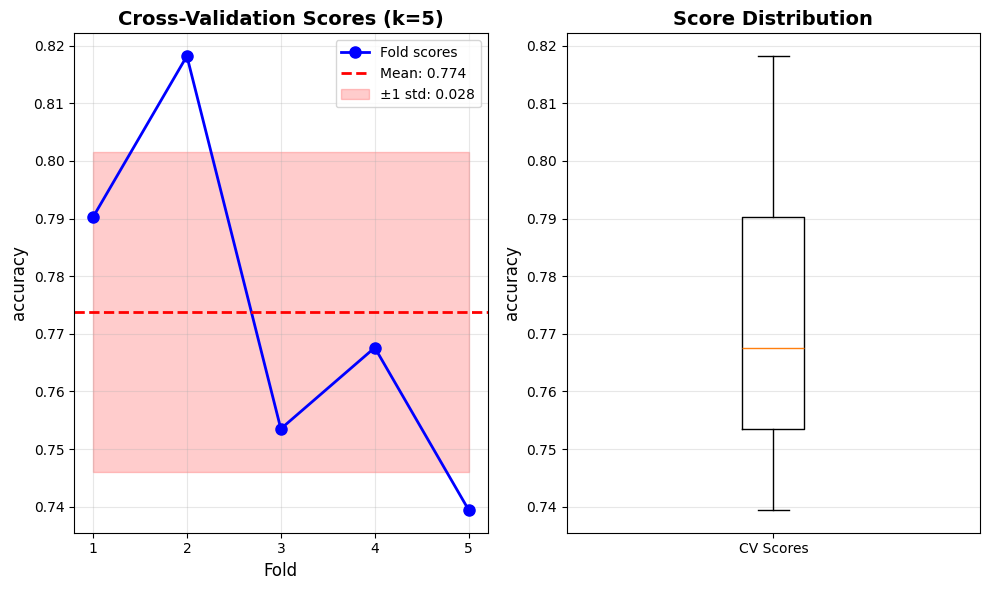

In [6]:
print("\n" + "="*70)
print("K-FOLD CROSS-VALIDATION")
print("="*70)

# Perform 5-fold cross-validation
cv_baseline = k_fold_cross_validation(
    model=model,  # Use same model as before
    X=X_train_proc,
    y=y_train,
    k=5,
    scoring='accuracy'
)

# Visualize
plot_cross_validation_results(cv_baseline)

## Dimensionality Reduction Visualization


PCA vs LDA VISUALIZATION

⚠️  LDA Auto-adjustment:
   Requested n_components: 2
   Maximum allowed (n_classes - 1): 1
   Using: 1 component(s)

💡 Binary classification detected:
   LDA can only produce 1 component for 2 classes
   This finds the single best line to separate classes

PCA vs LDA VISUALIZATION
Number of classes: 2
PCA type: Linear PCA
PCA components: 2
LDA components: 1

💡 Binary classification: Showing scatter plots + histograms


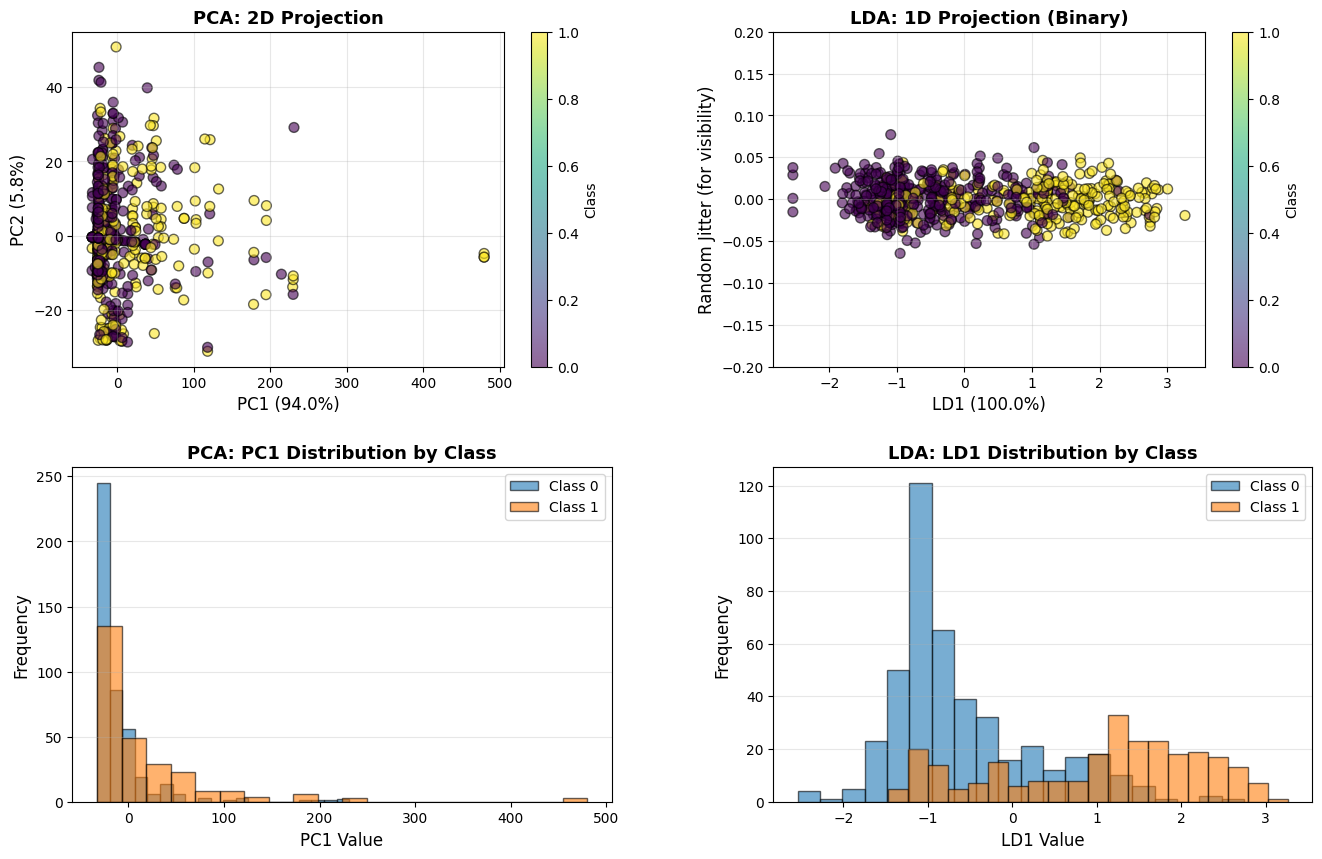


KEY INSIGHTS (Binary Classification)

💡 Why LDA only has 1 component:
   • For 2 classes, LDA can produce at most n_classes - 1 = 1 component
   • This finds the single best line to separate the two classes

💡 Notice in the histograms:
   • LDA (bottom right) shows better separation
   • PCA: Linear variance maximization
   • LDA: Supervised - maximizes class separation using labels

VARIANCE EXPLAINED

PCA: 99.9% total
  PC1: 94.0%
  PC2: 5.8%

LDA: 100.0% total
  LD1: 100.0%


In [7]:
print("\n" + "="*70)
print("PCA vs LDA VISUALIZATION")
print("="*70)

lda = SKLearnLDA(n_components=2)
lda.fit(X_train_proc, y_train)
lda.plot_comparison_with_pca(X_train_proc, y_train)

## Hyper-Parameter Tuning

In [ ]:
print("\n" + "="*70)
print("HYPERPARAMETER TUNING")
print("="*70)

# Define parameter grid based on model
param_grid = {
    # Decisin Tree
    'max_depth': [5, 10, 15, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

grid_results = grid_search_cv(
    model_class=SKLearnDecisionTreeClassifier,
    param_grid=param_grid,
    X=X_train_proc,
    y=y_train,
    cv=5,
    verbose=True
)

# Visualize grid search results (if 2 parameters)
if len(param_grid) >= 2:
    param_names = list(param_grid.keys())
    plot_grid_search_results(grid_results, param_names[0], param_names[1])

print(f"\n✓ Best parameters: {grid_results['best_params']}")
print(f"✓ Best CV score: {grid_results['best_score']:.4f}")


HYPERPARAMETER TUNING
GRID SEARCH WITH CROSS-VALIDATION
Parameter grid:
  max_depth: [5, 10, 15, 20, 30, 40, 50]

Total combinations to test: 7
Cross-validation folds: 5
Total fits: 35

K-FOLD CROSS-VALIDATION (k=5)
Task: Classification
Scoring: accuracy
Total samples: 712

Fold 1/5: accuracy=0.7762 (train: 569, test: 143)
Fold 2/5: accuracy=0.8322 (train: 569, test: 143)
Fold 3/5: accuracy=0.8099 (train: 570, test: 142)
Fold 4/5: accuracy=0.8239 (train: 570, test: 142)
Fold 5/5: accuracy=0.8099 (train: 570, test: 142)

CROSS-VALIDATION RESULTS
Mean accuracy: 0.8104 ± 0.0191
Min accuracy:  0.7762
Max accuracy:  0.8322
[1/7] {'max_depth': 5, 'random_state': 42}
  → accuracy: 0.8104 ± 0.0191

K-FOLD CROSS-VALIDATION (k=5)
Task: Classification
Scoring: accuracy
Total samples: 712

Fold 1/5: accuracy=0.7692 (train: 569, test: 143)
Fold 2/5: accuracy=0.8322 (train: 569, test: 143)
Fold 3/5: accuracy=0.8169 (train: 570, test: 142)
Fold 4/5: accuracy=0.7887 (train: 570, test: 142)
Fold 5/5: 

## Final Model Evaluation


FINAL MODEL EVALUATION
Test Accuracy: 0.7989

Confusion Matrix:


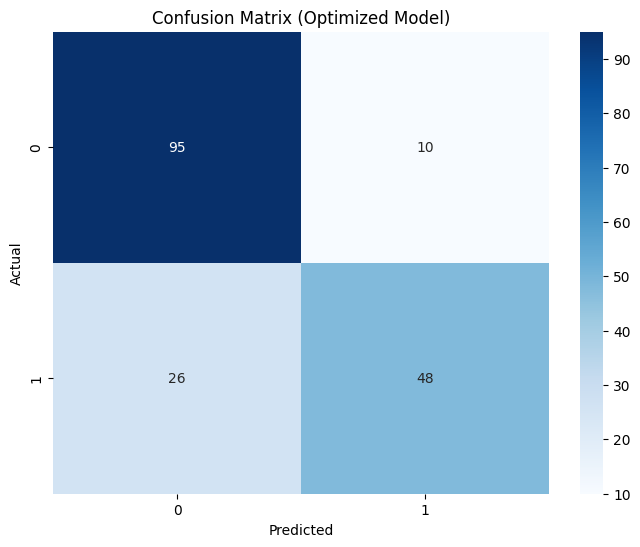


Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.90      0.84       105
           1       0.83      0.65      0.73        74

    accuracy                           0.80       179
   macro avg       0.81      0.78      0.78       179
weighted avg       0.80      0.80      0.79       179



In [9]:
best_model = grid_results['best_model']

final_score = best_model.score(X_test_proc, y_test)

print("\n" + "="*70)
print("FINAL MODEL EVALUATION")
print("="*70)
print(f"Test Accuracy: {final_score:.4f}")

print("\nConfusion Matrix:")
cm_final = best_model.confusion_matrix(X_test_proc, y_test)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix (Optimized Model)')
plt.show()

print("\nClassification Report:")
print(best_model.classification_report(X_test_proc, y_test))

## Model Comparison


MODEL COMPARISON
              Model  Accuracy       Std
0   Baseline (test)  0.776536       NaN
1     Baseline (CV)  0.773791  0.027819
2    Optimized (CV)  0.810411       NaN
3  Optimized (test)  0.798883       NaN


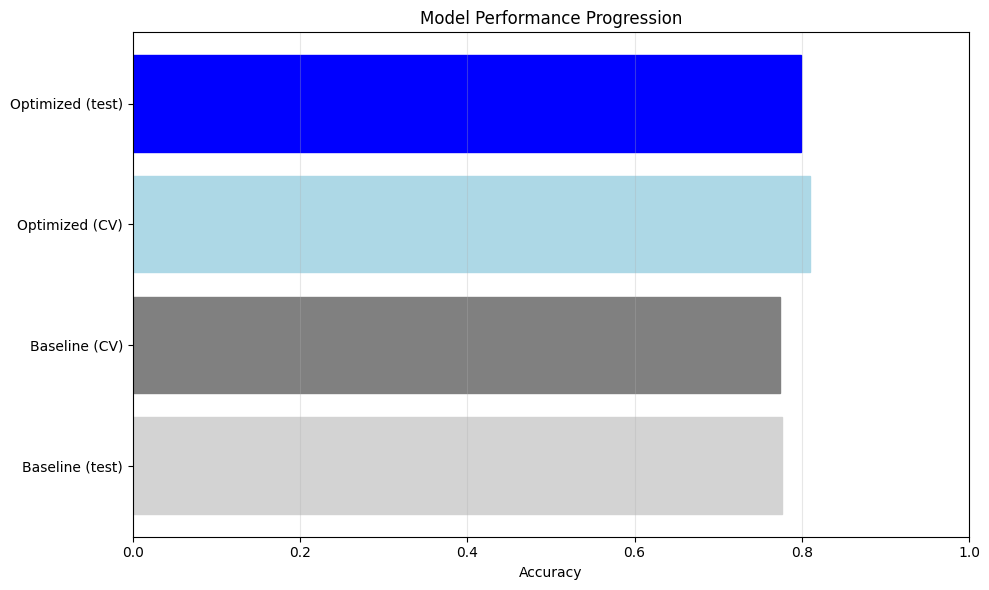


💡 Improvement from tuning: 2.23%


In [10]:
comparison_df = pd.DataFrame({
    'Model': ['Baseline (test)', 'Baseline (CV)', 'Optimized (CV)', 'Optimized (test)'],
    'Accuracy': [
        baseline_score,
        cv_baseline['mean'],
        grid_results['best_score'],
        final_score
    ],
    'Std': [None, cv_baseline['std'], None, None]
})

print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)
print(comparison_df)

# Visualize comparison
plt.figure(figsize=(10, 6))
bars = plt.barh(comparison_df['Model'], comparison_df['Accuracy'])
bars[0].set_color('lightgray')
bars[1].set_color('gray')
bars[2].set_color('lightblue')
bars[3].set_color('blue')
plt.xlabel('Accuracy')
plt.title('Model Performance Progression')
plt.xlim(0, 1)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print(f"\n💡 Improvement from tuning: {(final_score - baseline_score)*100:.2f}%")

## Feature Importance


FEATURE IMPORTANCE


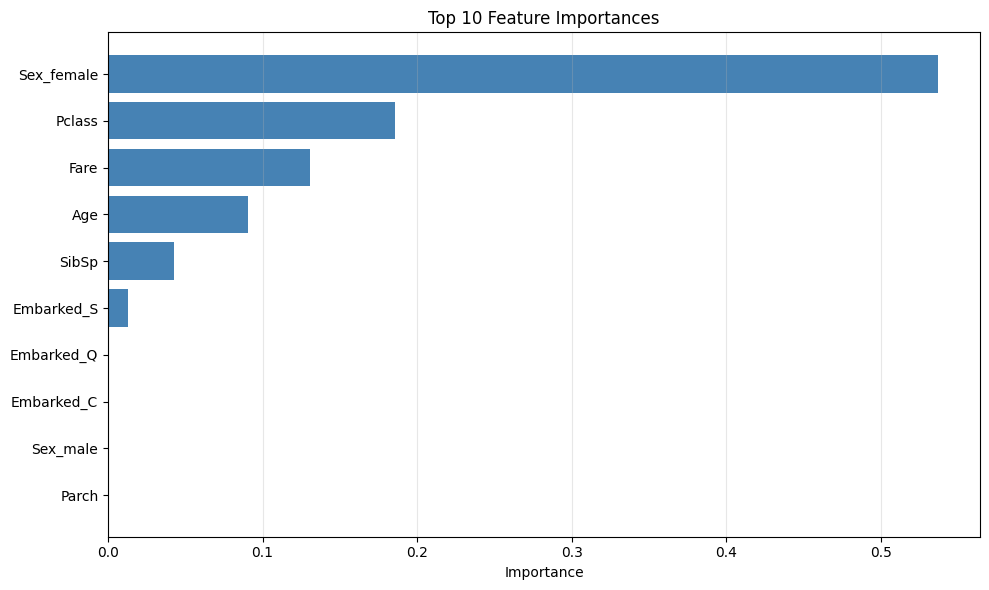


💡 Most important features:
   • Sex_female: 0.5374
   • Pclass: 0.1859
   • Fare: 0.1304
   • Age: 0.0906
   • SibSp: 0.0427


In [11]:
if hasattr(best_model, 'feature_importances_'):
    print("\n" + "="*70)
    print("FEATURE IMPORTANCE")
    print("="*70)
    
    importances = best_model.feature_importances_
    feature_names = preprocessor.get_feature_names()
    
    # Sort and plot top 10
    indices = np.argsort(importances)[-10:]
    
    plt.figure(figsize=(10, 6))
    plt.barh(range(len(indices)), importances[indices], color='steelblue')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel('Importance')
    plt.title('Top 10 Feature Importances')
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()
    
    print("\n💡 Most important features:")
    for idx in indices[::-1][:5]:  # Top 5
        print(f"   • {feature_names[idx]}: {importances[idx]:.4f}")

## Key Insights & Summary

In [12]:
print("\n" + "="*70)
print("KEY INSIGHTS")
print("="*70)
print(f"\n✓ Baseline accuracy: {baseline_score:.4f}")
print(f"✓ Optimized accuracy: {final_score:.4f}")
print(f"✓ Improvement: {(final_score - baseline_score)*100:.2f}%")
print(f"\n✓ Best hyperparameters found:")
for param, value in grid_results['best_params'].items():
    print(f"   • {param}: {value}")


KEY INSIGHTS

✓ Baseline accuracy: 0.7765
✓ Optimized accuracy: 0.7989
✓ Improvement: 2.23%

✓ Best hyperparameters found:
   • max_depth: 5
   • random_state: 42
